In [8]:
from reconstruction import MultiTreeReconstruction
import numpy as np
import json
import networkx as nx
import matplotlib.pyplot as plt

In [9]:
# class MultiTreeReconstruction:
#     """
#     Reconstruct multiple independent vascular trees from a single point cloud
#     """
#     def __init__(self, skeleton_points, n_trees=3, gamma=3.0, mu=3.6e-3, 
#                  Q_perf=0.125, P_out=60, P_in=100):
#         """
#         Parameters:
#         -----------
#         skeleton_points : np.array, shape (N, 3)
#             3D coordinates of skeleton points
#         n_trees : int
#             Expected number of separate trees to extract
#         gamma, mu, Q_perf, P_out, P_in : float
#             CCO physiological parameters (same as VascularTreeReconstruction)
#         """
#         self.original_points = np.array(skeleton_points)
#         self.n_trees = n_trees
#         self.gamma = gamma
#         self.mu = mu
#         self.Q_perf = Q_perf
#         self.P_out = P_out
#         self.P_in = P_in
        
#         self.trees = []  # List of reconstructed trees
#         self.remaining_points = self.original_points.copy()
#         self.point_to_tree_mapping = {}  # Maps original point index to tree index
        
#     def reconstruct_multiple_trees(self, k_neighbors_initial=5, k_neighbors_optimization=10,
#                                    min_tree_size=50, max_iterations=10):
#         """
#         Extract multiple trees iteratively
        
#         Parameters:
#         -----------
#         k_neighbors_initial : int
#             Low k for initial sparse connectivity (helps separate trees)
#         k_neighbors_optimization : int
#             Higher k for optimizing individual trees
#         min_tree_size : int
#             Minimum number of points required for a valid tree
#         max_iterations : int
#             Maximum number of trees to extract
        
#         Returns:
#         --------
#         trees : list of dict
#             List of tree structures, each containing:
#             - 'tree': networkx.DiGraph
#             - 'root': int (root node in original point indexing)
#             - 'radii': dict
#             - 'metrics': dict
#             - 'points': np.array (points for this tree)
#             - 'point_indices': list (indices in original point cloud)
#         """
#         print(f"Starting multi-tree reconstruction from {len(self.original_points)} points")
#         print(f"Target: {self.n_trees} trees\n")
        
#         iteration = 0
        
#         while len(self.remaining_points) >= min_tree_size and iteration < max_iterations:
#             iteration += 1
#             print(f"{'='*60}")
#             print(f"ITERATION {iteration}: {len(self.remaining_points)} points remaining")
#             print(f"{'='*60}\n")
            
#             # Extract one tree from remaining points
#             tree_data = self._extract_single_tree(
#                 k_neighbors_initial=k_neighbors_initial,
#                 k_neighbors_optimization=k_neighbors_optimization,
#                 min_tree_size=min_tree_size
#             )
            
#             if tree_data is None:
#                 print("No more valid trees found. Stopping.")
#                 break
            
#             self.trees.append(tree_data)
            
#             # Remove points belonging to this tree
#             self._remove_tree_points(tree_data)
            
#             print(f"\n✓ Tree {iteration} extracted: {len(tree_data['point_indices'])} points")
#             print(f"  Root at: {tree_data['points'][tree_data['root']]}")
#             print(f"  Terminals: {len([n for n in tree_data['tree'].nodes() if tree_data['tree'].out_degree(n) == 0])}")
#             print(f"  Total volume: {tree_data['metrics']['total_volume']:.2f} mm³")
#             print(f"  Remaining points: {len(self.remaining_points)}\n")
            
#             # Stop if we've extracted enough trees
#             if len(self.trees) >= self.n_trees:
#                 print(f"Extracted target number of trees ({self.n_trees}). Stopping.")
#                 break
        
#         print(f"\n{'='*60}")
#         print(f"FINAL RESULT: {len(self.trees)} trees extracted")
#         print(f"{'='*60}")
        
#         for i, tree_data in enumerate(self.trees):
#             print(f"Tree {i+1}: {len(tree_data['point_indices'])} points, "
#                   f"volume={tree_data['metrics']['total_volume']:.2f} mm³")
        
#         if len(self.remaining_points) > 0:
#             print(f"\nWarning: {len(self.remaining_points)} points not assigned to any tree")
        
#         return self.trees
    
#     def _extract_single_tree(self, k_neighbors_initial, k_neighbors_optimization, min_tree_size):
#         """
#         Extract one tree from remaining points using sparse connectivity
#         """
#         if len(self.remaining_points) < min_tree_size:
#             return None
        
#         # Step 1: Build sparse graph to identify connected components
#         print(f"Step 1: Building sparse graph (k={k_neighbors_initial})...")
#         sparse_graph = self._build_sparse_graph(self.remaining_points, k_neighbors_initial)
        
#         if sparse_graph.number_of_edges() == 0:
#             print("  No edges in sparse graph. Cannot extract tree.")
#             return None
        
#         # Step 2: Find largest connected component
#         print(f"Step 2: Finding connected components...")
#         components = list(nx.connected_components(sparse_graph))
#         print(f"  Found {len(components)} components")
        
#         if len(components) == 0:
#             return None
        
#         # Get largest component
#         largest_component = max(components, key=len)
#         print(f"  Largest component: {len(largest_component)} nodes")
        
#         if len(largest_component) < min_tree_size:
#             print(f"  Component too small (< {min_tree_size}). Skipping.")
#             return None
        
#         # Step 3: Extract points for this component
#         component_indices = sorted(list(largest_component))
#         component_points = self.remaining_points[component_indices]
        
#         print(f"Step 3: Extracting subgraph with {len(component_points)} points...")
        
#         # Step 4: Optimize this tree using standard CCO with higher k
#         print(f"Step 4: Optimizing tree (k={k_neighbors_optimization})...")
#         reconstructor = VascularTreeReconstruction(
#             component_points,
#             gamma=self.gamma,
#             mu=self.mu,
#             Q_perf=self.Q_perf,
#             P_out=self.P_out,
#             P_in=self.P_in
#         )
        
#         try:
#             tree, root, radii, metrics = reconstructor.reconstruct(
#                 k_neighbors=k_neighbors_optimization,
#                 n_candidates=5,
#                 optimize_bifurcations=True
#             )
#         except Exception as e:
#             print(f"  Failed to reconstruct tree: {e}")
#             return None
        
#         # Step 5: Map back to original point indices
#         # component_indices maps from component local indices to remaining_points indices
#         # We need to map to original point cloud indices
        
#         # Find original indices for these remaining points
#         original_indices = self._get_original_indices(component_indices)
        
#         tree_data = {
#             'tree': tree,
#             'root': root,  # Root in local component indexing
#             'radii': radii,
#             'metrics': metrics,
#             'points': component_points,
#             'point_indices': original_indices,  # Indices in original point cloud
#             'reconstructor': reconstructor
#         }
        
#         return tree_data
    
#     def _build_sparse_graph(self, points, k_neighbors):
#         """
#         Build a sparse k-NN graph (lower k helps separate disconnected trees)
#         """
#         from scipy.spatial import cKDTree
        
#         n_points = len(points)
#         tree = cKDTree(points)
        
#         # Create graph
#         G = nx.Graph()
        
#         # Add all nodes
#         for i in range(n_points):
#             G.add_node(i)
        
#         # Add k-NN edges
#         for i in range(n_points):
#             dists, indices = tree.query(points[i], k=min(k_neighbors+1, n_points))
#             for j, idx in enumerate(indices[1:]):  # Skip self
#                 if dists[j+1] < np.inf:
#                     G.add_edge(i, idx, weight=dists[j+1])
        
#         return G
    
#     def _get_original_indices(self, component_indices):
#         """
#         Map component indices (in remaining_points) back to original point cloud indices
#         """
#         # Build reverse mapping: remaining_points → original_points
#         original_indices = []
        
#         for comp_idx in component_indices:
#             remaining_point = self.remaining_points[comp_idx]
            
#             # Find this point in original cloud
#             # Use exact match (or nearest neighbor if points have been modified)
#             distances = np.linalg.norm(self.original_points - remaining_point, axis=1)
#             orig_idx = np.argmin(distances)
            
#             # Verify it's a close match
#             if distances[orig_idx] < 0.01:  # Should be exact or very close
#                 original_indices.append(orig_idx)
#             else:
#                 print(f"Warning: Could not find exact match for point {comp_idx}")
#                 original_indices.append(orig_idx)  # Use closest anyway
        
#         return original_indices
    
#     def _remove_tree_points(self, tree_data):
#         """
#         Remove points belonging to extracted tree from remaining points
#         """
#         # Get indices of points to remove (in remaining_points indexing)
#         points_to_remove = tree_data['points']
        
#         # Find which indices in remaining_points to keep
#         keep_mask = np.ones(len(self.remaining_points), dtype=bool)
        
#         for i, point in enumerate(self.remaining_points):
#             # Check if this point is in the extracted tree
#             distances = np.linalg.norm(points_to_remove - point, axis=1)
#             if np.min(distances) < 0.01:  # Point is in tree
#                 keep_mask[i] = False
        
#         # Update remaining points
#         self.remaining_points = self.remaining_points[keep_mask]
    
#     def visualize_all_trees(self, show_remaining=True):
#         """
#         Visualize all extracted trees in a single 3D plot
#         """
#         fig = plt.figure(figsize=(15, 12))
#         ax = fig.add_subplot(111, projection='3d')
        
#         # Color palette for different trees
#         colors = plt.cm.tab10(np.linspace(0, 1, len(self.trees)))
        
#         for tree_idx, tree_data in enumerate(self.trees):
#             tree = tree_data['tree']
#             points = tree_data['points']
#             radii = tree_data['radii']
#             root = tree_data['root']
#             color = colors[tree_idx]
            
#             # Draw edges
#             for u, v in tree.edges():
#                 pos_u = points[u]
#                 pos_v = points[v]
#                 radius = radii[v]
#                 linewidth = max(0.5, min(5, radius * 10))
                
#                 ax.plot([pos_u[0], pos_v[0]], 
#                        [pos_u[1], pos_v[1]], 
#                        [pos_u[2], pos_v[2]], 
#                        color=color, linewidth=linewidth, alpha=0.7)
            
#             # Highlight root
#             root_pos = points[root]
#             ax.scatter(*root_pos, c=[color], s=200, marker='o', 
#                       edgecolors='black', linewidths=2, 
#                       label=f'Tree {tree_idx+1} root')
            
#             # Show terminals
#             terminals = [n for n in tree.nodes() if tree.out_degree(n) == 0]
#             terminal_pos = points[terminals]
#             if len(terminal_pos) > 0:
#                 ax.scatter(terminal_pos[:, 0], terminal_pos[:, 1], terminal_pos[:, 2],
#                           c=[color], s=30, marker='^', alpha=0.5)
        
#         # Show remaining unassigned points
#         if show_remaining and len(self.remaining_points) > 0:
#             ax.scatter(self.remaining_points[:, 0], 
#                       self.remaining_points[:, 1], 
#                       self.remaining_points[:, 2],
#                       c='gray', s=5, alpha=0.3, label='Unassigned points')
        
#         ax.set_xlabel('X')
#         ax.set_ylabel('Y')
#         ax.set_zlabel('Z')
#         ax.legend()
#         ax.set_title(f'Multi-Tree Reconstruction ({len(self.trees)} trees)')
        
#         plt.tight_layout()
#         return fig, ax
    
#     def export_all_trees(self, base_filename):
#         """
#         Export all trees to separate JSON files for viewer
        
#         Parameters:
#         -----------
#         base_filename : str
#             Base name for output files (e.g., "hepatic_vein")
#             Will create: hepatic_vein_tree1.json, hepatic_vein_tree2.json, etc.
#         """
#         import json
        
#         for tree_idx, tree_data in enumerate(self.trees):
#             filename = f"{base_filename}_tree{tree_idx+1}.json"
            
#             tree = tree_data['tree']
#             points = tree_data['points']
#             radii = tree_data['radii']
            
#             branches = []
            
#             for parent, child in tree.edges():
#                 start_pos = points[parent].tolist()
#                 end_pos = points[child].tolist()
#                 radius = float(radii[child])
#                 Q = float(radius ** 3 * 100)
                
#                 branch = {
#                     "start": start_pos,
#                     "end": end_pos,
#                     "radius": radius,
#                     "Q": Q
#                 }
#                 branches.append(branch)
            
#             with open(filename, 'w') as f:
#                 json.dump(branches, f, indent=2)
            
#             print(f"Tree {tree_idx+1} exported to {filename} ({len(branches)} branches)")
    
#     def get_tree_statistics(self):
#         """
#         Print summary statistics for all trees
#         """
#         print(f"\n{'='*60}")
#         print(f"MULTI-TREE STATISTICS")
#         print(f"{'='*60}\n")
        
#         total_points = sum(len(t['point_indices']) for t in self.trees)
#         total_volume = sum(t['metrics']['total_volume'] for t in self.trees)
        
#         print(f"Total trees: {len(self.trees)}")
#         print(f"Total points assigned: {total_points} / {len(self.original_points)}")
#         print(f"Total volume: {total_volume:.2f} mm³")
#         print(f"Unassigned points: {len(self.remaining_points)}\n")
        
#         for i, tree_data in enumerate(self.trees):
#             print(f"Tree {i+1}:")
#             print(f"  Points: {len(tree_data['point_indices'])}")
#             print(f"  Root: {tree_data['points'][tree_data['root']]}")
            
#             tree = tree_data['tree']
#             terminals = [n for n in tree.nodes() if tree.out_degree(n) == 0]
#             bifurcations = [n for n in tree.nodes() 
#                            if tree.out_degree(n) == 2 and tree.in_degree(n) == 1]
            
#             print(f"  Terminals: {len(terminals)}")
#             print(f"  Bifurcations: {len(bifurcations)}")
#             print(f"  Volume: {tree_data['metrics']['total_volume']:.2f} mm³")
#             print(f"  Murray error: {tree_data['metrics']['murray_error_mean']:.4f}")
            
#             radii_values = list(tree_data['radii'].values())
#             print(f"  Radius range: [{min(radii_values):.3f}, {max(radii_values):.3f}] mm")
#             print()




In [10]:
# Example usages

def example_multi_tree_usage():
    """
    Example: Extract multiple hepatic vein trees from skeleton
    """
    # Load your skeleton points
    skeleton_points = np.load('hepatic_skeleton.npy')  # Shape: (N, 3)
    
    # Or generate synthetic data for testing
    # skeleton_points = generate_multi_tree_test_data()
    
    # Initialize multi-tree reconstructor
    reconstructor = MultiTreeReconstruction(
        skeleton_points,
        n_trees=3,  # Expect 3 major hepatic veins
        gamma=3.0,
        mu=3.6e-3,
        Q_perf=0.125,
        P_out=60,
        P_in=100
    )
    
    # Extract multiple trees
    trees = reconstructor.reconstruct_multiple_trees(
        k_neighbors_initial=5,      # Low k for separation
        k_neighbors_optimization=10, # Higher k for optimization
        min_tree_size=50,            # Minimum points per tree
        max_iterations=10            # Safety limit
    )
    
    # Print statistics
    reconstructor.get_tree_statistics()
    
    # Visualize all trees together
    fig, ax = reconstructor.visualize_all_trees(show_remaining=True)
    plt.show()
    
    # Export for viewer
    reconstructor.export_all_trees('hepatic_veins')
    
    return reconstructor, trees


def generate_multi_tree_test_data():
    """
    Generate synthetic skeleton with 3 separate trees for testing
    """
    np.random.seed(42)
    all_points = []
    
    # Tree 1: Right hepatic vein
    trunk1 = []
    for i in range(30):
        trunk1.append([20 + i*0.5, 10 + i*0.3, i])
    for _ in range(50):
        base = trunk1[np.random.randint(0, len(trunk1))]
        offset = np.random.randn(3) * 3
        trunk1.append(base + offset)
    all_points.extend(trunk1)
    
    # Tree 2: Middle hepatic vein
    trunk2 = []
    for i in range(30):
        trunk2.append([0 + i*0.3, 15 + i*0.4, i])
    for _ in range(50):
        base = trunk2[np.random.randint(0, len(trunk2))]
        offset = np.random.randn(3) * 3
        trunk2.append(base + offset)
    all_points.extend(trunk2)
    
    # Tree 3: Left hepatic vein
    trunk3 = []
    for i in range(30):
        trunk3.append([-20 + i*0.4, 20 + i*0.2, i])
    for _ in range(50):
        base = trunk3[np.random.randint(0, len(trunk3))]
        offset = np.random.randn(3) * 3
        trunk3.append(base + offset)
    all_points.extend(trunk3)
    
    return np.array(all_points)


# if __name__ == "__main__":
    # Run example
    # reconstructor, trees = example_multi_tree_usage()

Starting multi-tree reconstruction from 1432 points
Target: 3 trees

ITERATION 1: 1432 points remaining

Using root candidate method: highest_z
Step 1: Building sparse graph (k=3)...
Step 2: Finding connected components...
  Found 15 components
  Largest component: 973 nodes
Step 3: Extracting subgraph with 973 points...
Step 4: Optimizing tree (k=10)...
Building graph from skeleton points...
Graph built: 973 nodes, 972 edges
Found 5 candidates from superior endpoints
Found 5 root candidates

Evaluating 5 root candidates...

Candidate 1/5: node 960
  Terminals: 71, Total nodes: 973
  Optimizing 70 bifurcations...
  Metrics: volume=0.03, murray_error=0.0000, radius_violations=0

Candidate 2/5: node 956
  Terminals: 71, Total nodes: 973
  Optimizing 70 bifurcations...
  Metrics: volume=0.03, murray_error=0.0000, radius_violations=0

Candidate 3/5: node 958
  Terminals: 71, Total nodes: 973
  Optimizing 70 bifurcations...
  Metrics: volume=0.01, murray_error=0.0000, radius_violations=0

C

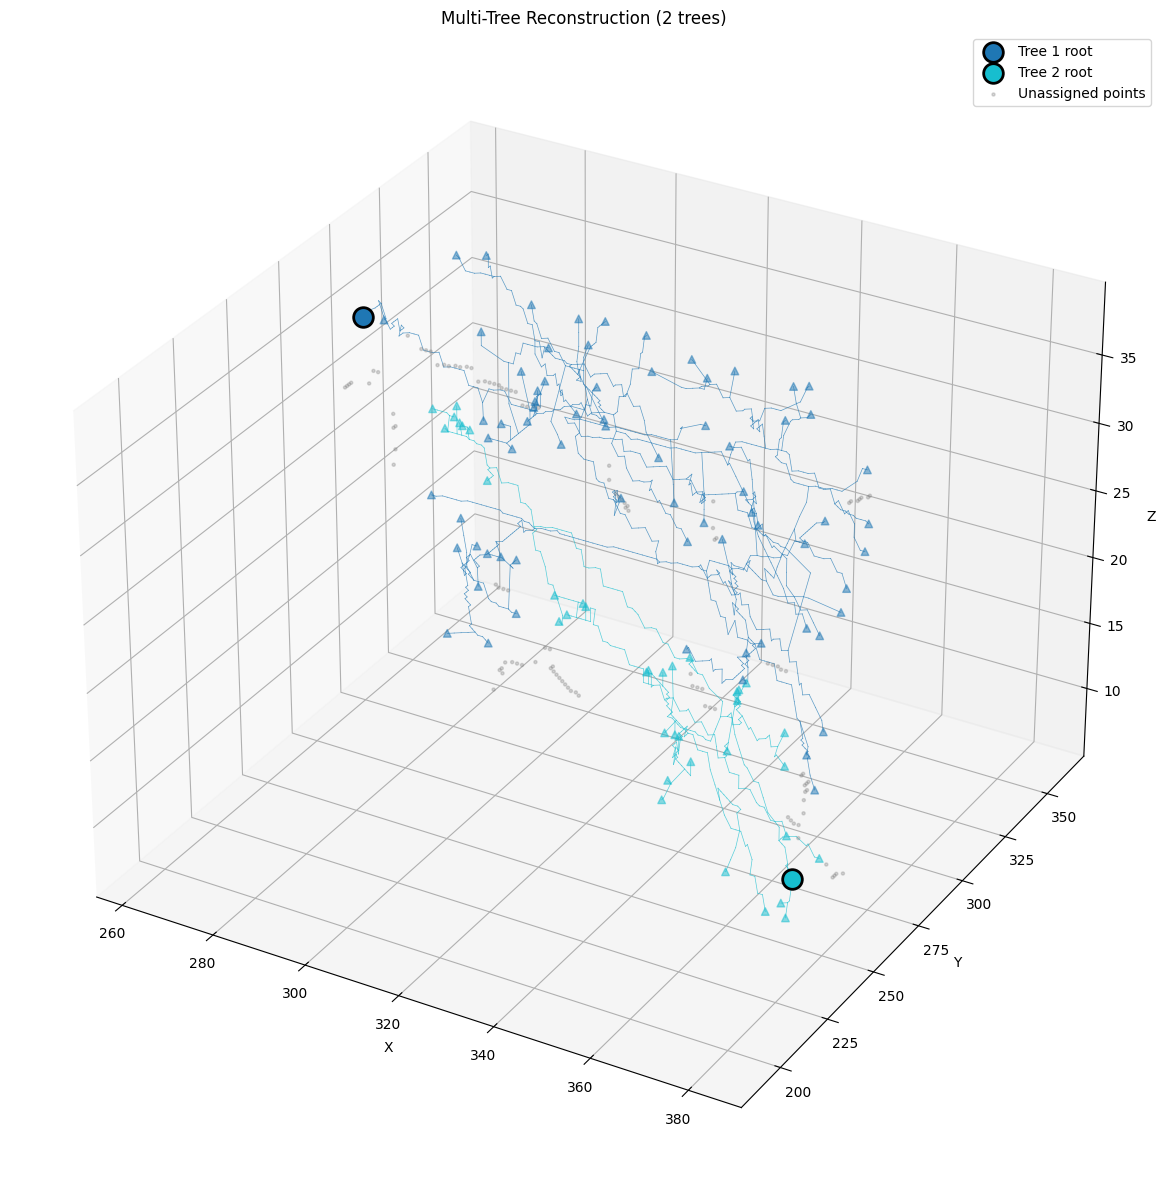

Tree 1 exported to test-data/1hepatic_veins_tree1.json (972 branches)
Tree 2 exported to test-data/1hepatic_veins_tree2.json (345 branches)


In [ ]:
# thinning = load_thinning(nib.load("../skeleton-viewer/data/hepaticvessel_001.nii.gz")[0])
thinning = json.load(open("../zenodo_skeletons/Task08_HepaticVessel/skeletons/hepaticvessel_001_LNC.json", 'r'))

reconstructor = MultiTreeReconstruction(
    thinning,
    n_trees=3,  # Expect 3 major hepatic veins
    gamma=3.0,
    mu=3.6e-3,
    Q_perf=0.125,
    P_out=60,
    P_in=100
)

# Extract multiple trees
trees = reconstructor.reconstruct_multiple_trees(
    k_neighbors_initial=3,      # Low k for separation
    k_neighbors_optimization=10, # Higher k for optimization
    min_tree_size=10,            # Minimum points per tree
    max_iterations=10            # Safety limit
    methods=["highest_z", "highest_z", "lowest_z"]  # Different root selection for each tree
)

# Print statistics
reconstructor.get_tree_statistics()

# Visualize all trees together
fig, ax = reconstructor.visualize_all_trees(show_remaining=True)
plt.show()

# Export for viewer
reconstructor.export_all_trees('test-data/1hepatic_veins')

